In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.linear_model import LinearRegression


In [162]:
df = pd.read_csv("marketing_campaigns.csv")
df['revenue_generated'] = df['revenue_generated'] / 1000000
df['campaign_cost'] = df['campaign_cost'] / 1000000
DirectApp = df[df['channel'] == 'Direct/App']
SocialMediaInstagram = df[df['channel'] == 'Social Media - Instagram']
OrganicSearch = df[df['channel'] == 'Organic Search']
SMSMarketing = df[df['channel'] == 'SMS Marketing']
EmailMarketing = df[df['channel'] == 'Email Marketing']
Referral = df[df['channel'] == 'Referral']
Affiliate = df[df['channel'] == 'Affiliate']
PaidSearch = df[df['channel'] == 'Paid Search']
SocialMediaFacebook = df[df['channel'] == 'Social Media - Facebook']
InfluencerMarketing = df[df['channel'] == 'Influencer Marketing']

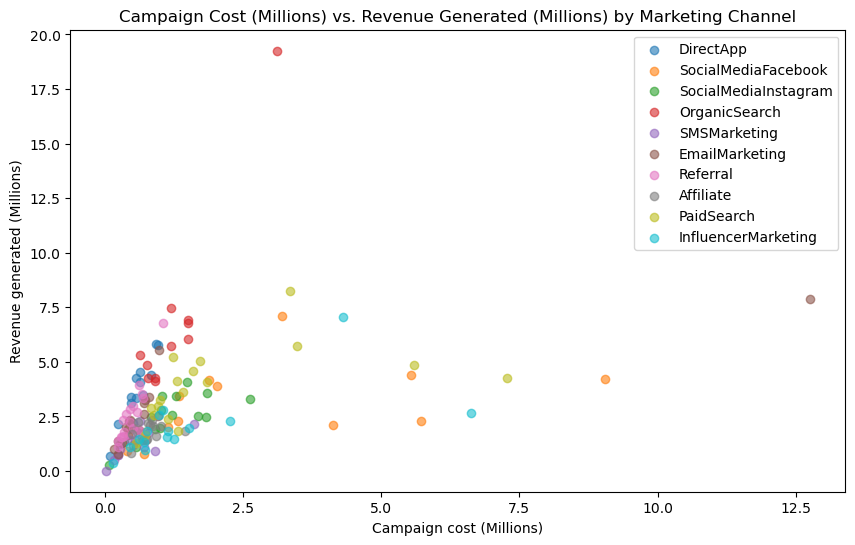

In [163]:
channels = {
    "DirectApp": DirectApp,
    "SocialMediaFacebook": SocialMediaFacebook,
    "SocialMediaInstagram": SocialMediaInstagram,
    "OrganicSearch": OrganicSearch,
    "SMSMarketing": SMSMarketing,
    "EmailMarketing": EmailMarketing,
    "Referral": Referral,
    "Affiliate": Affiliate,
    "PaidSearch": PaidSearch,
    "InfluencerMarketing": InfluencerMarketing
}

plt.figure(figsize=(10, 6))

for channel_name, data in channels.items():
    sample = data

    plt.scatter(
        sample["campaign_cost"],
        sample["revenue_generated"],
        alpha=0.6,
        label=channel_name
    )

plt.title("Campaign Cost (Millions) vs. Revenue Generated (Millions) by Marketing Channel")
plt.xlabel("Campaign cost (Millions)")
plt.ylabel("Revenue generated (Millions)")
plt.locator_params(axis="x", nbins=6)
plt.legend()
plt.show()

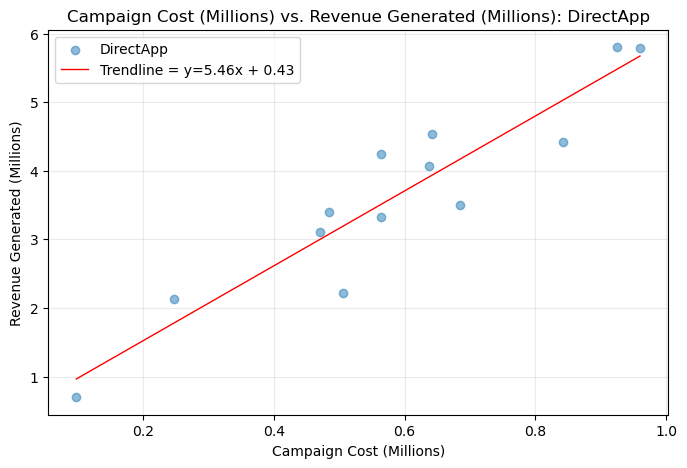

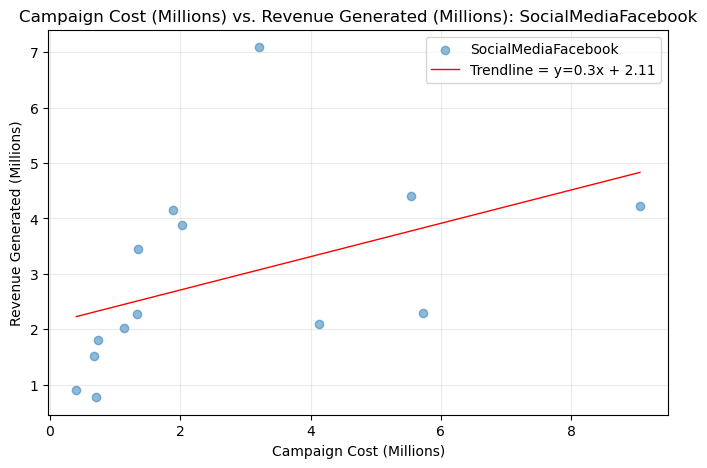

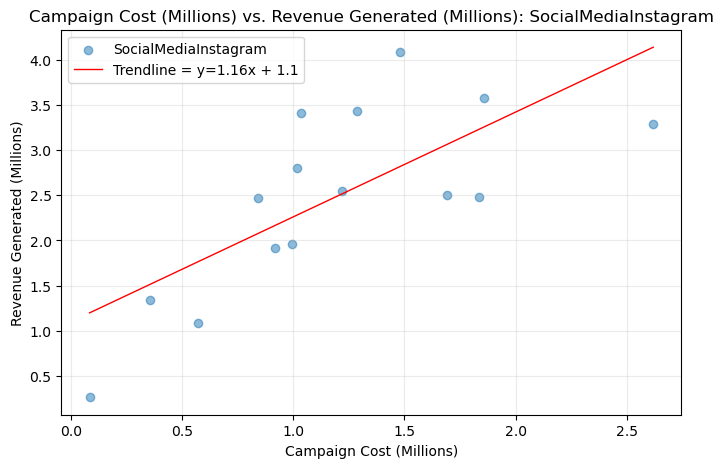

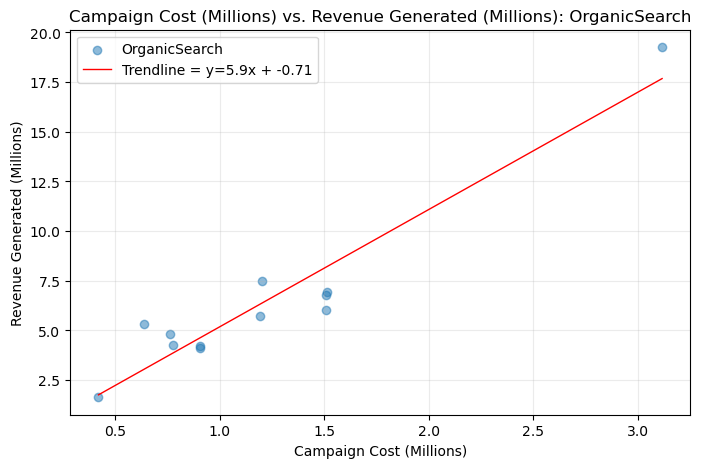

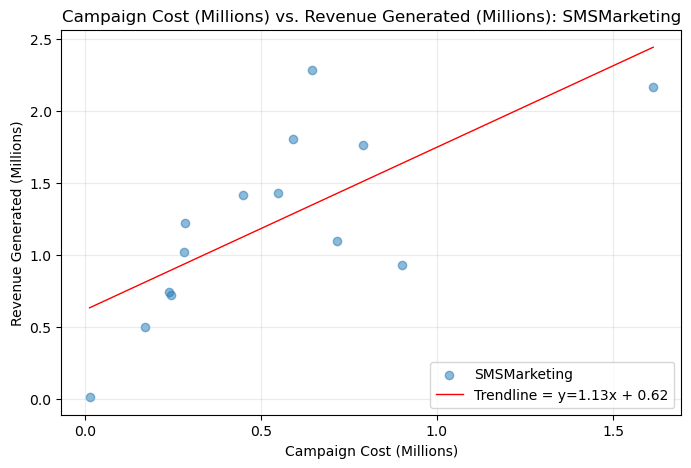

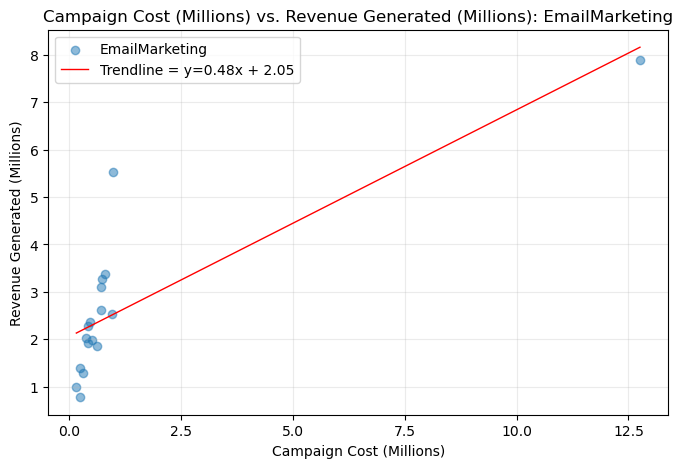

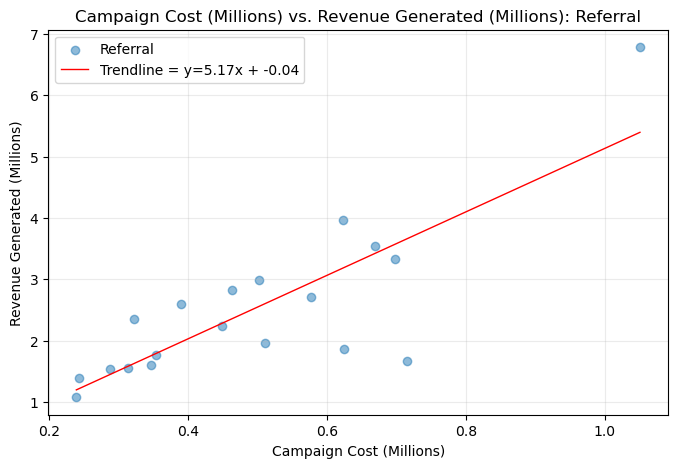

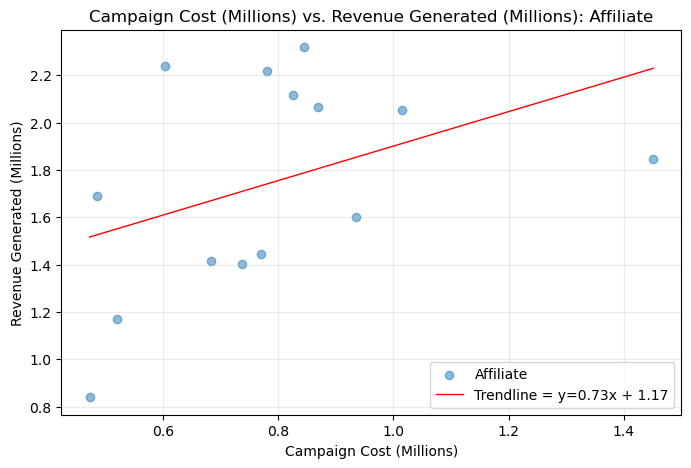

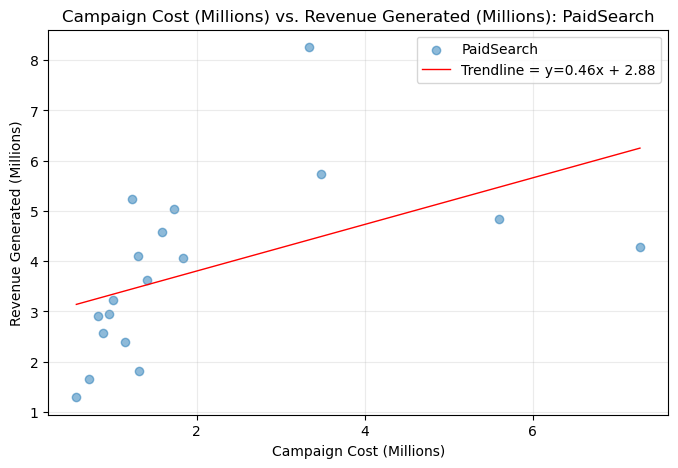

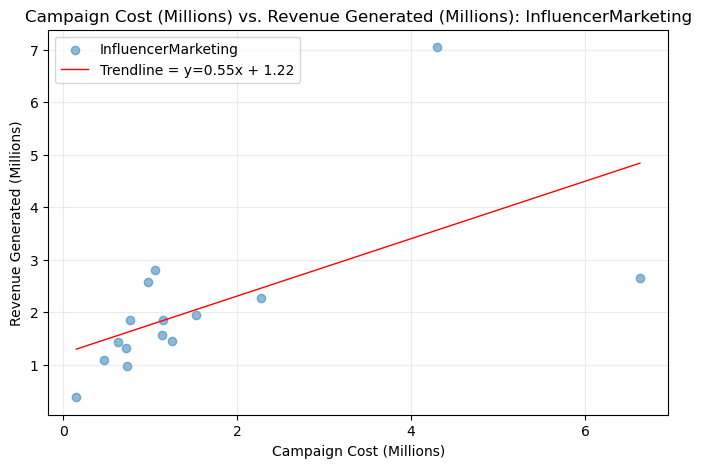

In [164]:
for channel_name, data in channels.items():
    plt.figure(figsize=(8, 5))
    plt.scatter(
    data["campaign_cost"],
    data["revenue_generated"],
    alpha=0.5,
    label=channel_name
)
    reg = LinearRegression().fit(data[["campaign_cost"]], data[["revenue_generated"]])
    slope, intercept = np.polyfit(
    data["campaign_cost"],
    data["revenue_generated"],
    1
)
    x_values = np.linspace(
    data["campaign_cost"].min(),
    data["campaign_cost"].max(),
    100
)
    plt.plot(
    x_values,
    slope * x_values + intercept,
    color="red",
    linewidth=1,
    label="Trendline = y=" + str(round(slope, 2)) + "x + " + str(round(intercept, 2))
)
    plt.title("Campaign Cost (Millions) vs. Revenue Generated (Millions): " + str(channel_name))
    plt.xlabel("Campaign Cost (Millions)")
    plt.ylabel("Revenue Generated (Millions)")
    plt.locator_params(axis="x", nbins=6)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()







DirectApp
Trendline: y = 5.46x + 0.43
R-squared: 0.872


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


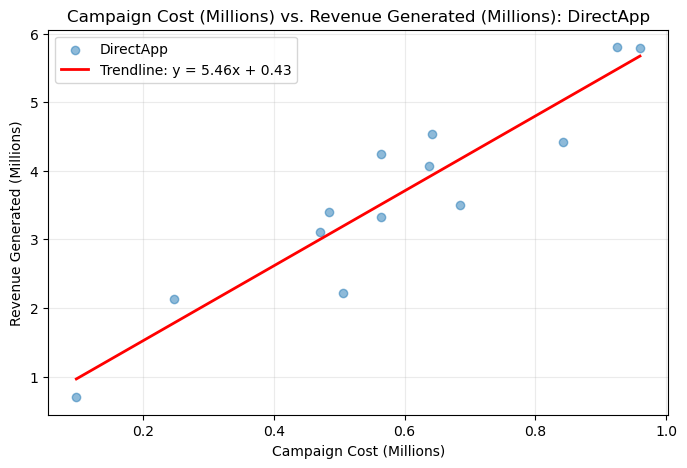

SocialMediaFacebook
Trendline: y = 0.30x + 2.11
R-squared: 0.200


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


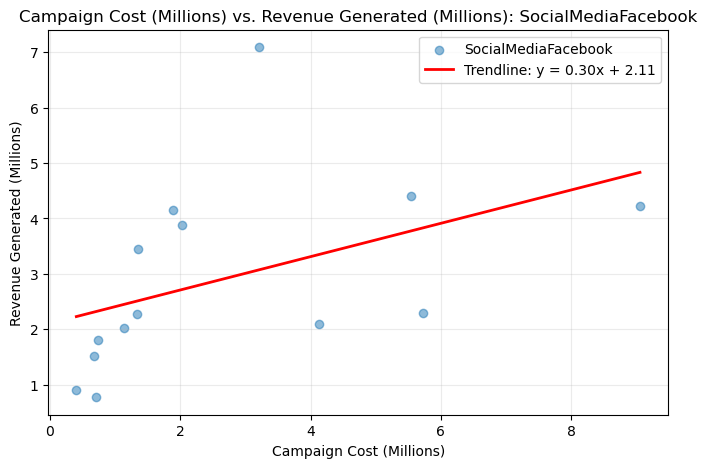

SocialMediaInstagram
Trendline: y = 1.16x + 1.10
R-squared: 0.521


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


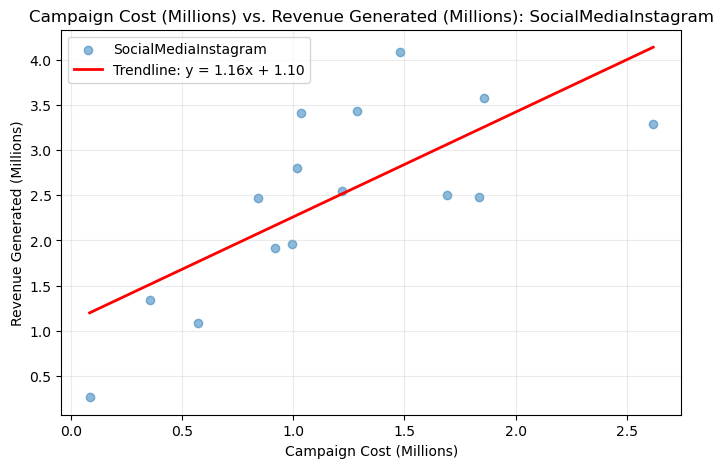

OrganicSearch
Trendline: y = 5.90x + -0.71
R-squared: 0.909


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


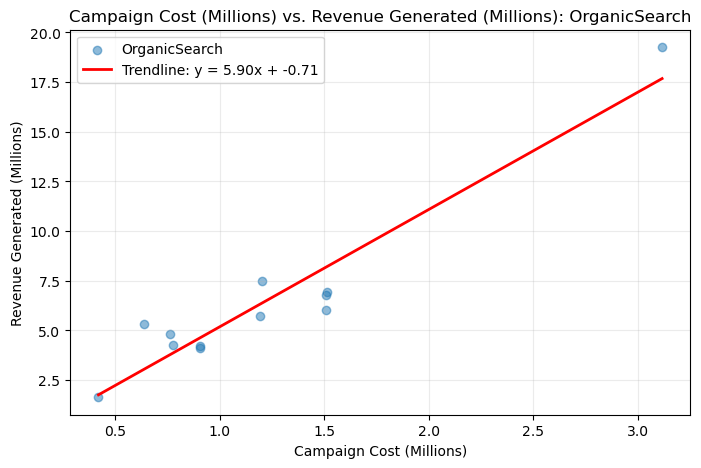

SMSMarketing
Trendline: y = 1.13x + 0.62
R-squared: 0.508


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


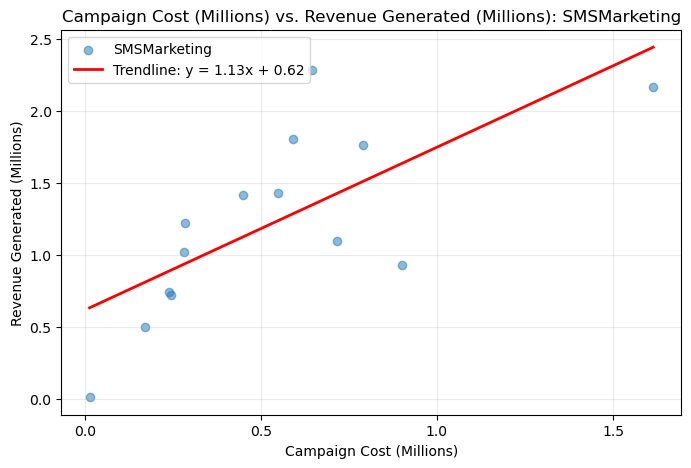

EmailMarketing
Trendline: y = 0.48x + 2.05
R-squared: 0.662


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


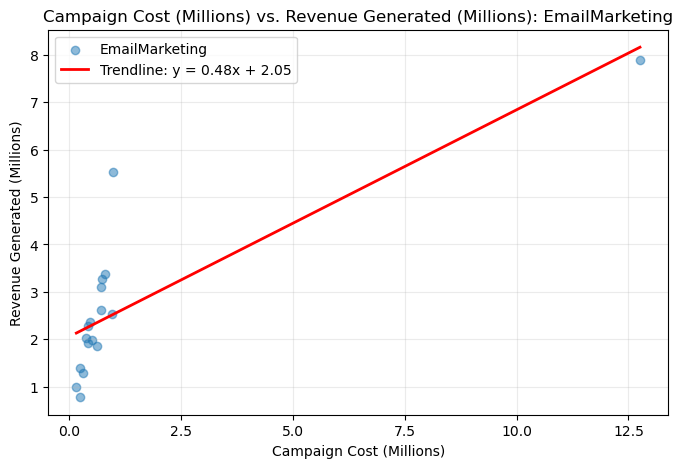

Referral
Trendline: y = 5.17x + -0.04
R-squared: 0.665


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


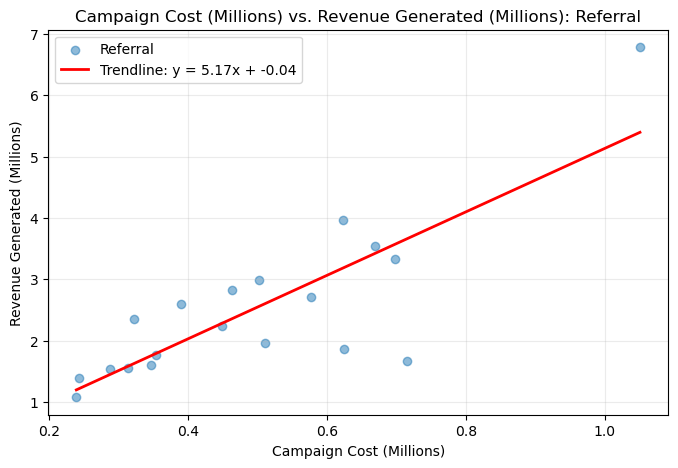

Affiliate
Trendline: y = 0.73x + 1.17
R-squared: 0.168


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


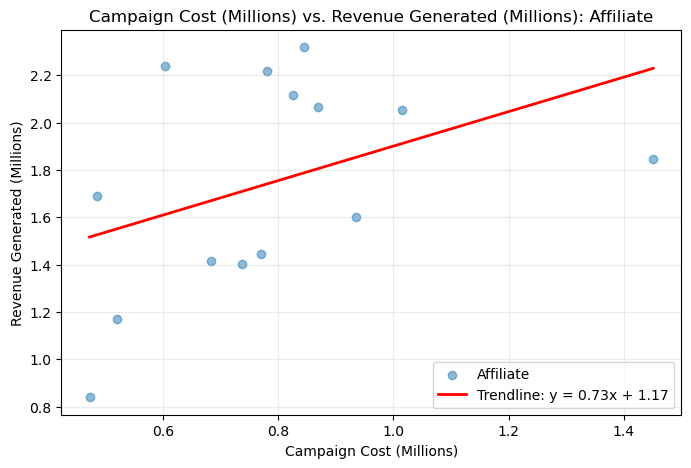

PaidSearch
Trendline: y = 0.46x + 2.88
R-squared: 0.243


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


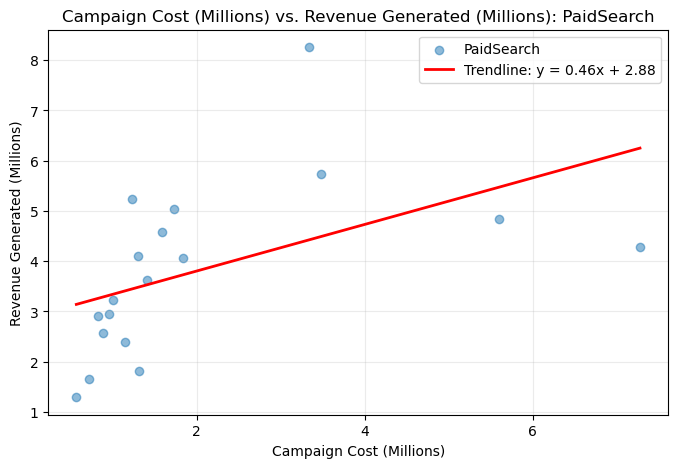

InfluencerMarketing
Trendline: y = 0.55x + 1.22
R-squared: 0.373


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


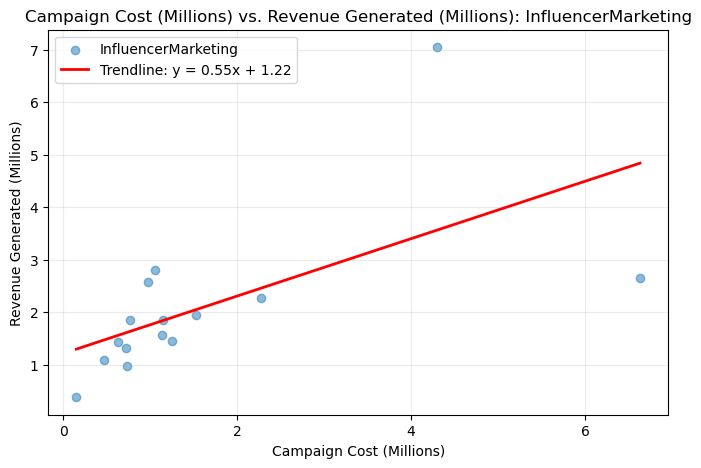

In [173]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
for channel_name, data in channels.items():

    # Keep only rows with valid values in both variables
    clean_data = data.dropna(
        subset=["campaign_cost", "revenue_generated"]
    )

    # Create and fit the regression model
    reg = LinearRegression()
    reg.fit(
        clean_data[["campaign_cost"]],      # X must be 2D: double brackets
        clean_data["revenue_generated"]     # y can be 1D: single brackets
    )

    # Extract the equation components
    slope = reg.coef_[0]
    intercept = reg.intercept_
    r_squared = reg.score(
        clean_data[["campaign_cost"]],
        clean_data["revenue_generated"]
    )
    print(channel_name)
    print(f"Trendline: y = {slope:.2f}x + {intercept:.2f}")
    print(f"R-squared: {r_squared:.3f}")

    # Make evenly spaced cost values for a smooth trendline
    x_values = np.linspace(
        clean_data["campaign_cost"].min(),
        clean_data["campaign_cost"].max(),
        100
    )

    # predict() requires its input to be 2D
    y_values = reg.predict(x_values.reshape(-1, 1))

    # Plot points
    plt.figure(figsize=(8, 5))

    plt.scatter(
        clean_data["campaign_cost"],
        clean_data["revenue_generated"],
        alpha=0.5,
        label=channel_name
    )

    # Plot LinearRegression trendline
    plt.plot(
        x_values,
        y_values,
        color="red",
        linewidth=2,
        label=f"Trendline: y = {slope:.2f}x + {intercept:.2f}"
    )

    plt.title(f"Campaign Cost (Millions) vs. Revenue Generated (Millions): {channel_name}")
    plt.xlabel("Campaign Cost (Millions)")
    plt.ylabel("Revenue Generated (Millions)")
    plt.locator_params(axis="x", nbins=6)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

/var/folders/r3/qrsz5xf14t1g_nyryt513mlh0000gn/T/ipykernel_8479/3230076626.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


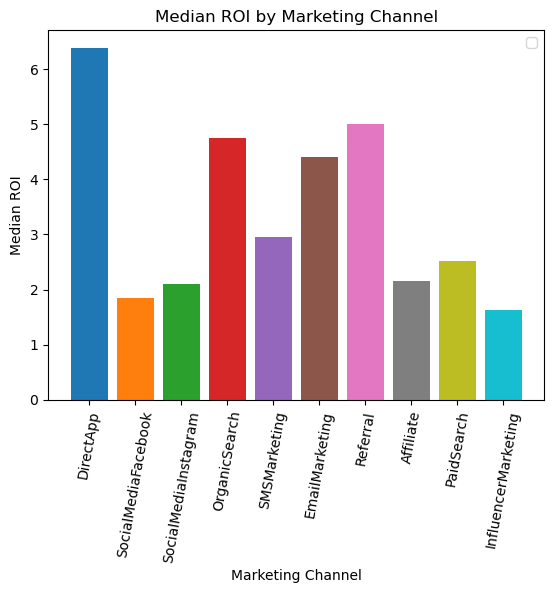

In [ ]:
for channel_name, data in channels.items():
    roi = data["revenue_generated"] / data["campaign_cost"] if not data.empty else 0
    medianroi = roi.median() if not roi.empty else 0
    plt.bar(
        channel_name,
        medianroi,
        0.8,
    )

plt.title("Median ROI by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Median ROI")
plt.xticks(rotation=80)
plt.legend()
plt.show()

/var/folders/r3/qrsz5xf14t1g_nyryt513mlh0000gn/T/ipykernel_8479/278130562.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


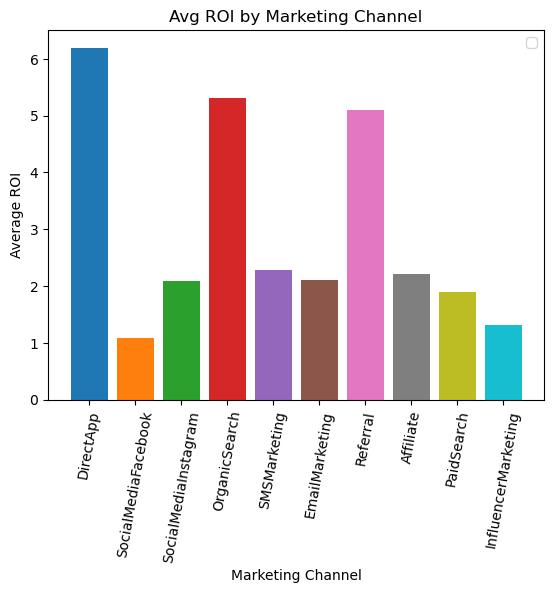

In [ ]:
for channel_name, data in channels.items():
    avgroi = data["revenue_generated"].mean() / data["campaign_cost"].mean() if not data.empty else 0

    plt.bar(
        channel_name,
        avgroi,
        0.8,
    )

plt.title("Avg ROI by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average ROI")
plt.xticks(rotation=80)
plt.legend()
plt.show()